In [ ]:
### MOUNT DRIVE
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


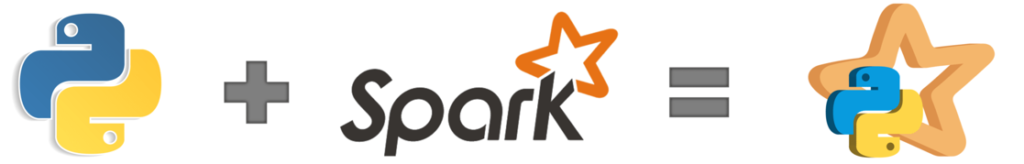

In [ ]:
### PLATFORM CONFIGURATION (OPTIONAL)
# Install pyspark
!pip install pyspark
# Import SparkSession
from pyspark.sql import SparkSession
# Create a Spark Session
spark = SparkSession.builder.master("local[*]").getOrCreate()
# Check Spark Session Information
spark
# Import a Spark function from library
from pyspark.sql.functions import col

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.4/281.4 MB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 KB 20.8 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.3.1-py2.py3-none-any.whl size=281845512 sha256=ea54ee29f994a71f520b4178623aad535bcb2ebbadca9bacdbde39b2d7cd01c8
  Stored in directory: /root/.cache/pip/wheels/43/dc/11/ec201cd671da62fa9c5cc77078235e40722170ceba231d7598
Successfully built pyspark


In [ ]:
## WAYS TO LOADING DATA INTO DATA FRAME (Different Data Set)
from pyspark.sql.types import *

dfemp1 = spark.read.format("csv").option("header","True").load('/content/drive/MyDrive/spark_workspace/Data_Files/original.csv')
dfemp1.show()

dfemp2 = spark.read.csv('/content/drive/MyDrive/spark_workspace/Data_Files/original.csv',header=True)
dfemp2.show()

userSchema = StructType([
    StructField('employee_id',IntegerType()),
    StructField('ename',StringType()),
    StructField('salary',FloatType()),
])
dfemp3 = spark.read.csv('/content/drive/MyDrive/spark_workspace/Data_Files/original.csv',header=True,schema=userSchema)
dfemp3.show()

+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+
| id|first_name| last_name|gender|           City|            JobTitle|   Salary|  Latitude|  Longitude|
+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+
|  1|   Melinde| Shilburne|Female|      Nowa Ruda| Assistant Professor|$57438.18|50.5774075| 16.4967184|
|  2|  Kimberly|Von Welden|Female|         Bulgan|       Programmer II|$62846.60|48.8231572|103.5218199|
|  3|    Alvera|  Di Boldi|Female|           null|                null|$57576.52|39.9947462|116.3397725|
|  4|   Shannon| O'Griffin|  Male|  Divnomorskoye|Budget/Accounting...|$61489.23|44.5047212| 38.1300171|
|  5|  Sherwood|   Macieja|  Male|      Mytishchi|            VP Sales|$63863.09|      null| 37.6489954|
|  6|     Maris|      Folk|Female|Kinsealy-Drinan|      Civil Engineer|$30101.16|53.4266145| -6.1644997|
|  7|     Masha|    Divers|Female|         Dachun|     

In [ ]:
### LOADING THE CSV DATA INTO DATA FRAME WITH HEADER OPTION ENABLEMENT
mydata = spark.read.format("csv").option("header","true").load("/content/drive/MyDrive/spark_workspace/Data_Files/original.csv")
### DISPLAY THE DATA SET
mydata.show()

+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+
| id|first_name| last_name|gender|           City|            JobTitle|   Salary|  Latitude|  Longitude|
+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+
|  1|   Melinde| Shilburne|Female|      Nowa Ruda| Assistant Professor|$57438.18|50.5774075| 16.4967184|
|  2|  Kimberly|Von Welden|Female|         Bulgan|       Programmer II|$62846.60|48.8231572|103.5218199|
|  3|    Alvera|  Di Boldi|Female|           null|                null|$57576.52|39.9947462|116.3397725|
|  4|   Shannon| O'Griffin|  Male|  Divnomorskoye|Budget/Accounting...|$61489.23|44.5047212| 38.1300171|
|  5|  Sherwood|   Macieja|  Male|      Mytishchi|            VP Sales|$63863.09|      null| 37.6489954|
|  6|     Maris|      Folk|Female|Kinsealy-Drinan|      Civil Engineer|$30101.16|53.4266145| -6.1644997|
|  7|     Masha|    Divers|Female|         Dachun|     

In [ ]:
### LOADING THE CSV DATA INTO DATA FRAME WITHOUT HEADER OPTION
mydata_Temp = spark.read.format("csv").load("/content/drive/MyDrive/spark_workspace/Data_Files/original.csv")
mydata_Temp.show()

+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+
|_c0|       _c1|       _c2|   _c3|            _c4|                 _c5|      _c6|       _c7|        _c8|
+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+
| id|first_name| last_name|gender|           City|            JobTitle|   Salary|  Latitude|  Longitude|
|  1|   Melinde| Shilburne|Female|      Nowa Ruda| Assistant Professor|$57438.18|50.5774075| 16.4967184|
|  2|  Kimberly|Von Welden|Female|         Bulgan|       Programmer II|$62846.60|48.8231572|103.5218199|
|  3|    Alvera|  Di Boldi|Female|           null|                null|$57576.52|39.9947462|116.3397725|
|  4|   Shannon| O'Griffin|  Male|  Divnomorskoye|Budget/Accounting...|$61489.23|44.5047212| 38.1300171|
|  5|  Sherwood|   Macieja|  Male|      Mytishchi|            VP Sales|$63863.09|      null| 37.6489954|
|  6|     Maris|      Folk|Female|Kinsealy-Drinan|     

In [ ]:
### NEW COLUMN CREATE WITH SOME CONDITION
from pyspark.sql.functions import *

mydata2 = mydata.withColumn("Clean_City",when(mydata.City.isNull(),'Unknown').otherwise(mydata.City))
mydata2.show()

+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+---------------+
| id|first_name| last_name|gender|           City|            JobTitle|   Salary|  Latitude|  Longitude|     Clean_City|
+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+---------------+
|  1|   Melinde| Shilburne|Female|      Nowa Ruda| Assistant Professor|$57438.18|50.5774075| 16.4967184|      Nowa Ruda|
|  2|  Kimberly|Von Welden|Female|         Bulgan|       Programmer II|$62846.60|48.8231572|103.5218199|         Bulgan|
|  3|    Alvera|  Di Boldi|Female|           null|                null|$57576.52|39.9947462|116.3397725|        Unknown|
|  4|   Shannon| O'Griffin|  Male|  Divnomorskoye|Budget/Accounting...|$61489.23|44.5047212| 38.1300171|  Divnomorskoye|
|  5|  Sherwood|   Macieja|  Male|      Mytishchi|            VP Sales|$63863.09|      null| 37.6489954|      Mytishchi|
|  6|     Maris|      Folk|Femal

In [ ]:
### MODIFY EXISTING DATASET BY DOING SOME FILTER ON ANY COLUMN
mydata2 = mydata2.filter(mydata2.JobTitle.isNotNull())
mydata2.show()

+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+---------------+
| id|first_name| last_name|gender|           City|            JobTitle|   Salary|  Latitude|  Longitude|     Clean_City|
+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+---------------+
|  1|   Melinde| Shilburne|Female|      Nowa Ruda| Assistant Professor|$57438.18|50.5774075| 16.4967184|      Nowa Ruda|
|  2|  Kimberly|Von Welden|Female|         Bulgan|       Programmer II|$62846.60|48.8231572|103.5218199|         Bulgan|
|  4|   Shannon| O'Griffin|  Male|  Divnomorskoye|Budget/Accounting...|$61489.23|44.5047212| 38.1300171|  Divnomorskoye|
|  5|  Sherwood|   Macieja|  Male|      Mytishchi|            VP Sales|$63863.09|      null| 37.6489954|      Mytishchi|
|  6|     Maris|      Folk|Female|Kinsealy-Drinan|      Civil Engineer|$30101.16|53.4266145| -6.1644997|Kinsealy-Drinan|
|  8|   Goddart|     Flear|  Mal

In [ ]:
### MODIFY EXISTING DATASET BY ADDING NEW CCOLUMN AND CATSING DATA TYPE
mydata2 = mydata2.withColumn('clean_salary',mydata2.Salary.substr(2,100).cast('float'))
mydata2.show()

+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+---------------+------------+
| id|first_name| last_name|gender|           City|            JobTitle|   Salary|  Latitude|  Longitude|     Clean_City|clean_salary|
+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+---------------+------------+
|  1|   Melinde| Shilburne|Female|      Nowa Ruda| Assistant Professor|$57438.18|50.5774075| 16.4967184|      Nowa Ruda|    57438.18|
|  2|  Kimberly|Von Welden|Female|         Bulgan|       Programmer II|$62846.60|48.8231572|103.5218199|         Bulgan|     62846.6|
|  4|   Shannon| O'Griffin|  Male|  Divnomorskoye|Budget/Accounting...|$61489.23|44.5047212| 38.1300171|  Divnomorskoye|    61489.23|
|  5|  Sherwood|   Macieja|  Male|      Mytishchi|            VP Sales|$63863.09|      null| 37.6489954|      Mytishchi|    63863.09|
|  6|     Maris|      Folk|Female|Kinsealy-Drinan|      Civil 

In [ ]:
### AGGREGATE FUNCTION (DETERMINE AVG SALARY)
mean = mydata2.groupby().avg('clean_salary')
mean.show()
mean = mydata2.groupby().avg('clean_salary').take(1)[0][0]
print(mean)

+-----------------+
|avg(clean_salary)|
+-----------------+
|55516.32088199837|
+-----------------+

55516.32088199837


In [ ]:
### USAGE OF LITERALS
from pyspark.sql.functions import lit

mydata2 = mydata2.withColumn('new_salary',when(mydata2.clean_salary.isNull(),lit(mean)).otherwise(mydata2.clean_salary))
mydata2.show()

+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+---------------+------------+----------------+
| id|first_name| last_name|gender|           City|            JobTitle|   Salary|  Latitude|  Longitude|     Clean_City|clean_salary|      new_salary|
+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+---------------+------------+----------------+
|  1|   Melinde| Shilburne|Female|      Nowa Ruda| Assistant Professor|$57438.18|50.5774075| 16.4967184|      Nowa Ruda|    57438.18|   57438.1796875|
|  2|  Kimberly|Von Welden|Female|         Bulgan|       Programmer II|$62846.60|48.8231572|103.5218199|         Bulgan|     62846.6|   62846.6015625|
|  4|   Shannon| O'Griffin|  Male|  Divnomorskoye|Budget/Accounting...|$61489.23|44.5047212| 38.1300171|  Divnomorskoye|    61489.23|  61489.23046875|
|  5|  Sherwood|   Macieja|  Male|      Mytishchi|            VP Sales|$63863.09|      null| 3

In [ ]:
# SELECT OPERATION (SPECIFIED COLUMNS)
mydata_Temp = mydata2.select(mydata2.id,'first_name','last_name','gender','Clean_City','JobTitle','new_salary','Latitude','Longitude')
mydata_Temp.show()

+---+----------+----------+------+---------------+--------------------+----------------+----------+-----------+
| id|first_name| last_name|gender|     Clean_City|            JobTitle|      new_salary|  Latitude|  Longitude|
+---+----------+----------+------+---------------+--------------------+----------------+----------+-----------+
|  1|   Melinde| Shilburne|Female|      Nowa Ruda| Assistant Professor|   57438.1796875|50.5774075| 16.4967184|
|  2|  Kimberly|Von Welden|Female|         Bulgan|       Programmer II|   62846.6015625|48.8231572|103.5218199|
|  4|   Shannon| O'Griffin|  Male|  Divnomorskoye|Budget/Accounting...|  61489.23046875|44.5047212| 38.1300171|
|  5|  Sherwood|   Macieja|  Male|      Mytishchi|            VP Sales|  63863.08984375|      null| 37.6489954|
|  6|     Maris|      Folk|Female|Kinsealy-Drinan|      Civil Engineer|  30101.16015625|53.4266145| -6.1644997|
|  8|   Goddart|     Flear|  Male|      Trélissac|Desktop Support T...|    46116.359375|45.1905186|  0.7

In [ ]:
# REMOVE DUPLICATE ROWS
mydata_Temp = mydata_Temp.dropDuplicates()
mydata_Temp.show()

+---+----------+---------+------+--------------------+--------------------+---------------+-----------+-----------+
| id|first_name|last_name|gender|          Clean_City|            JobTitle|     new_salary|   Latitude|  Longitude|
+---+----------+---------+------+--------------------+--------------------+---------------+-----------+-----------+
|106|      Kory|    Sayre|  Male|                Caen|  Office Assistant I|  81237.2109375|  49.285973| -0.4889547|
|413|   Sherrie|    Siely|Female|                Arys|Senior Cost Accou...|  55981.2109375| 42.4338529| 68.8129042|
|611|    Ileane| Tolliday|Female|              Clichy|       Programmer II|        26236.0| 48.9089753|  2.3011787|
|650|      Esra|  Tilston|  Male|    Velyka Lepetykha|        Food Chemist|  66552.3203125| 47.1634031| 33.9366442|
|919|     Catie|   Aubrun|Female|            Chunghwa| Structural Engineer|13757.669921875| 38.8605311|125.7898106|
| 21|      Alon| Chasteau|  Male|               Xin’e|     Web Developer

In [ ]:
### MEDIAN CALCULATION USING NUMPY LIBRARY
import numpy

# select column
latitude = mydata2.select('Latitude')
# modify selected column by removing null values
latitude = latitude.filter(latitude.Latitude.isNotNull())
# create new column and override existng one & peform type casting
latitude = latitude.withColumn('latitude2',latitude.Latitude.cast('float')).select('latitude2')
# latitude.show()
# determine mean value using numpy 
median = numpy.median(latitude.collect())
print(median)


31.93397331237793


In [ ]:
### USAGE OF LITERALS
mydata2 = mydata2.withColumn('lat',when(mydata2.Latitude.isNull(),lit(median)).otherwise(mydata2.Latitude))
mydata2.show()

+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+---------------+------------+----------------+-----------------+
| id|first_name| last_name|gender|           City|            JobTitle|   Salary|  Latitude|  Longitude|     Clean_City|clean_salary|      new_salary|              lat|
+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+---------------+------------+----------------+-----------------+
|  1|   Melinde| Shilburne|Female|      Nowa Ruda| Assistant Professor|$57438.18|50.5774075| 16.4967184|      Nowa Ruda|    57438.18|   57438.1796875|       50.5774075|
|  2|  Kimberly|Von Welden|Female|         Bulgan|       Programmer II|$62846.60|48.8231572|103.5218199|         Bulgan|     62846.6|   62846.6015625|       48.8231572|
|  4|   Shannon| O'Griffin|  Male|  Divnomorskoye|Budget/Accounting...|$61489.23|44.5047212| 38.1300171|  Divnomorskoye|    61489.23|  61489.23046875|     

In [ ]:
### GROUPBY FUNCTION (Average salary Male vs Female)
from pyspark.sql.functions import *

genders = mydata2.groupBy('gender').agg(avg('new_salary'))
genders.show()

+------+------------------+
|gender|   avg(new_salary)|
+------+------------------+
|Female|55677.250125558036|
|  Male| 55361.09385573019|
+------+------------------+



In [ ]:
mydata3 = mydata2.withColumn('female_salary',when(mydata2.gender == 'Female',mydata2.new_salary).otherwise(lit(0)))
mydata3 = mydata3.withColumn('male_salary',when(mydata2.gender == 'Male',mydata3.new_salary).otherwise(lit(0)))
mydata3.show()

+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+---------------+------------+----------------+-----------------+----------------+----------------+
| id|first_name| last_name|gender|           City|            JobTitle|   Salary|  Latitude|  Longitude|     Clean_City|clean_salary|      new_salary|              lat|   female_salary|     male_salary|
+---+----------+----------+------+---------------+--------------------+---------+----------+-----------+---------------+------------+----------------+-----------------+----------------+----------------+
|  1|   Melinde| Shilburne|Female|      Nowa Ruda| Assistant Professor|$57438.18|50.5774075| 16.4967184|      Nowa Ruda|    57438.18|   57438.1796875|       50.5774075|   57438.1796875|             0.0|
|  2|  Kimberly|Von Welden|Female|         Bulgan|       Programmer II|$62846.60|48.8231572|103.5218199|         Bulgan|     62846.6|   62846.6015625|       48.8231572|   62846.6015625|   

In [ ]:
### USAGE OF ALIAS
mydata3 = mydata3.groupBy('JobTitle').agg(avg('female_salary').alias('final_female_salary'),avg('male_salary').alias('final_male_salary'))
mydata3.show()

+--------------------+-------------------+------------------+
|            JobTitle|final_female_salary| final_male_salary|
+--------------------+-------------------+------------------+
|Systems Administr...|    50590.474609375|  15540.9501953125|
|   Media Manager III| 29586.436197916668|17381.920572916668|
|  Recruiting Manager| 34848.452473958336|  26383.4951171875|
|       Geologist III|       31749.046875|    12830.75390625|
|        Geologist II|                0.0|   43293.865234375|
|Database Administ...|                0.0|     52018.4609375|
|   Financial Analyst|    23353.776953125|       39606.05625|
|  Analyst Programmer|   16406.1287109375|  21042.9634765625|
|Software Engineer II|                0.0|      74782.640625|
|       Accountant IV|    82732.248046875|               0.0|
|    Product Engineer|     41825.48359375|       20464.94375|
|Software Test Eng...|   32218.6083984375|   27122.462890625|
|Safety Technician...|                0.0|   29421.529296875|
|    Jun

In [ ]:
### NEW COLUMN WITH MATHEMATICAL CALCULATION (DELATA COLUMN)
df_delta = mydata3.withColumn('delta',mydata3.final_female_salary - mydata3.final_male_salary)
df_delta.show()

+--------------------+-------------------+------------------+-------------------+
|            JobTitle|final_female_salary| final_male_salary|              delta|
+--------------------+-------------------+------------------+-------------------+
|Systems Administr...|    50590.474609375|  15540.9501953125|   35049.5244140625|
|   Media Manager III| 29586.436197916668|17381.920572916668|       12204.515625|
|  Recruiting Manager| 34848.452473958336|  26383.4951171875|  8464.957356770836|
|       Geologist III|       31749.046875|    12830.75390625|     18918.29296875|
|        Geologist II|                0.0|   43293.865234375|   -43293.865234375|
|Database Administ...|                0.0|     52018.4609375|     -52018.4609375|
|   Financial Analyst|    23353.776953125|       39606.05625|   -16252.279296875|
|  Analyst Programmer|   16406.1287109375|  21042.9634765625| -4636.834765625001|
|Software Engineer II|                0.0|      74782.640625|      -74782.640625|
|       Accounta

In [ ]:
### DATA SORTING
cityavg = mydata2.groupBy('City').agg(avg('new_salary').alias('City_Avg_Sal'))
cityavg = cityavg.sort(col('City_Avg_Sal').desc())
cityavg.show()

+-----------------+-------------+
|             City| City_Avg_Sal|
+-----------------+-------------+
|        Mesopotam|  99948.28125|
|       Zhongcheng| 99942.921875|
|           Caxias|99786.3984375|
|      Karangtawar|99638.9921875|
|        Itabaiana|  99502.15625|
|           Pasian|  99421.34375|
|           Webuye| 99368.546875|
|      Yuktae-dong| 99250.828125|
|           Zinder|  99222.84375|
|   Timiryazevskiy|   99142.9375|
|        Sawahbaru|99013.7109375|
|          Madimba|98737.8671875|
|         Huangshi|  98690.34375|
|          Gharyan|   98679.3125|
|         Yŏnan-ŭp| 98628.609375|
|     Wringinputih|98603.8203125|
|Monte da Boavista|  98586.71875|
|          Klukeng|98439.4921875|
|         Murmashi|  98226.15625|
|        Fox Creek|      98138.0|
+-----------------+-------------+
only showing top 20 rows



In [ ]:
### FIRST n ROWS FROM A DATASET
mydata_Temp.head(5)

[Row(id='106', first_name='Kory', last_name='Sayre', gender='Male', Clean_City='Caen', JobTitle='Office Assistant I', new_salary=81237.2109375, Latitude='49.285973', Longitude='-0.4889547'),
 Row(id='413', first_name='Sherrie', last_name='Siely', gender='Female', Clean_City='Arys', JobTitle='Senior Cost Accountant', new_salary=55981.2109375, Latitude='42.4338529', Longitude='68.8129042'),
 Row(id='611', first_name='Ileane', last_name='Tolliday', gender='Female', Clean_City='Clichy', JobTitle='Programmer II', new_salary=26236.0, Latitude='48.9089753', Longitude='2.3011787'),
 Row(id='650', first_name='Esra', last_name='Tilston', gender='Male', Clean_City='Velyka Lepetykha', JobTitle='Food Chemist', new_salary=66552.3203125, Latitude='47.1634031', Longitude='33.9366442'),
 Row(id='919', first_name='Catie', last_name='Aubrun', gender='Female', Clean_City='Chunghwa', JobTitle='Structural Engineer', new_salary=13757.669921875, Latitude='38.8605311', Longitude='125.7898106')]

In [ ]:
### DESCRIBE THE FULL TABLE
mydata_Temp.describe().show()

+-------+-----------------+----------+---------+------+-------------------+-------------------+-----------------+------------------+------------------+
|summary|               id|first_name|last_name|gender|         Clean_City|           JobTitle|       new_salary|          Latitude|         Longitude|
+-------+-----------------+----------+---------+------+-------------------+-------------------+-----------------+------------------+------------------+
|  count|              998|       998|      998|   998|                998|                998|              998|               997|               998|
|   mean|501.4929859719439|      null|     null|  null|               null|               null|55516.32088199837|25.417463954764276|43.188672075150336|
| stddev|288.2542088463841|      null|     null|  null|               null|               null|25863.13933185166| 24.59940996985679|  69.4103341375263|
|    min|                1|   Abagail|    Abbay|Female|             Abéché|Account Coord

In [ ]:
### GET THE COLUMN LIST ONLY
mydata.columns

['id',
 'first_name',
 'last_name',
 'gender',
 'City',
 'JobTitle',
 'Salary',
 'Latitude',
 'Longitude']

In [ ]:
### TOTAL NUMBER OF ROWS IN A DATASET
mydata.count()

1000

In [ ]:
### TOTAL NUMBER OF UNIQUE ROWS IN A DATASET
mydata.distinct().count()

1000

In [ ]:
### OTHER FILTER OPERATIONS
mydata_Temp_filter = mydata_Temp.filter(mydata_Temp.first_name == 'Melinde')
mydata_Temp_filter.show()

mydata_Temp_filter = mydata_Temp.filter(mydata_Temp.first_name.like('%din'))
mydata_Temp_filter.show()

mydata_Temp_filter = mydata_Temp.filter(mydata_Temp.id.between(1,3))
mydata_Temp_filter.show()

mydata_Temp_filter = mydata_Temp.filter(mydata_Temp.first_name.isin('Melinde','Valma'))
mydata_Temp_filter.show()

+---+----------+---------+------+----------+-------------------+-------------+----------+----------+
| id|first_name|last_name|gender|Clean_City|           JobTitle|   new_salary|  Latitude| Longitude|
+---+----------+---------+------+----------+-------------------+-------------+----------+----------+
|  1|   Melinde|Shilburne|Female| Nowa Ruda|Assistant Professor|57438.1796875|50.5774075|16.4967184|
+---+----------+---------+------+----------+-------------------+-------------+----------+----------+

+---+----------+-------------+------+-----------+--------+------------+-----------+----------+
| id|first_name|    last_name|gender| Clean_City|JobTitle|  new_salary|   Latitude| Longitude|
+---+----------+-------------+------+-----------+--------+------------+-----------+----------+
|901|     Aldin|Matuszkiewicz|  Male|East London|Operator|41468.828125|-32.9549324|27.9319131|
+---+----------+-------------+------+-----------+--------+------------+-----------+----------+

+---+----------+--

In [ ]:
### LOGICAL OPERATORS
mydata_Temp_filter = mydata_Temp.filter((mydata_Temp.first_name.isin('Melinde','Valma')) & (mydata_Temp.Clean_City.like('%shi')))
mydata_Temp_filter.show()

mydata_Temp_filter = mydata_Temp.filter((mydata_Temp.first_name.isin('Melinde','Valma')) | (mydata_Temp.Clean_City.like('%don')))
mydata_Temp_filter.show()


+---+----------+---------+------+----------+----------------+------------+----------+-----------+
| id|first_name|last_name|gender|Clean_City|        JobTitle|  new_salary|  Latitude|  Longitude|
+---+----------+---------+------+----------+----------------+------------+----------+-----------+
|569|     Valma|  Bratton|Female| Kurayoshi|Web Developer II|32665.890625|35.4499037|133.7613311|
+---+----------+---------+------+----------+----------------+------------+----------+-----------+

+---+----------+-------------+------+-----------+-------------------+-------------+-----------+-----------+
| id|first_name|    last_name|gender| Clean_City|           JobTitle|   new_salary|   Latitude|  Longitude|
+---+----------+-------------+------+-----------+-------------------+-------------+-----------+-----------+
|  1|   Melinde|    Shilburne|Female|  Nowa Ruda|Assistant Professor|57438.1796875| 50.5774075| 16.4967184|
|257|     Leese|     Filewood|Female|  Nyaungdon|Biostatistician III| 32445.6

In [ ]:
### MORE WITH SELECT
mydata_Temp_select = mydata_Temp.select(mydata_Temp.first_name,mydata_Temp.first_name.substr(1,4).alias('SubStr_name'))
mydata_Temp_select.show()

+----------+-----------+
|first_name|SubStr_name|
+----------+-----------+
|      Kory|       Kory|
|   Sherrie|       Sher|
|    Ileane|       Ilea|
|      Esra|       Esra|
|     Catie|       Cati|
|      Alon|       Alon|
|     Zolly|       Zoll|
|    Amitie|       Amit|
|   Honoria|       Hono|
|   Lurleen|       Lurl|
|   Hadrian|       Hadr|
|     Kaela|       Kael|
|     Irene|       Iren|
|     Verne|       Vern|
|   Almeria|       Alme|
|      Aime|       Aime|
|   Humfrid|       Humf|
|    Saudra|       Saud|
|    Curran|       Curr|
| Michaella|       Mich|
+----------+-----------+
only showing top 20 rows



In [ ]:
### AGGREGATE OPERATION EXTENDED
mydata_Temp_grp = mydata_Temp.groupby("gender").agg(sum("new_salary").alias("Total_salary"),
                                                    avg("new_salary").alias("Avg_salary"),
                                                    max("new_salary").alias("maximum_salary"),
                                                    min("new_salary").alias("minimum_salary"))
mydata_Temp_grp.show()


mydata_Temp_grp = mydata_Temp.groupby("Clean_City").agg(sum("new_salary").alias("Total_salary"),
                                                    avg("new_salary").alias("Avg_salary"),
                                                    max("new_salary").alias("maximum_salary"),
                                                    min("new_salary").alias("minimum_salary"))
mydata_Temp_grp.show()

+------+--------------------+------------------+--------------+----------------+
|gender|        Total_salary|        Avg_salary|maximum_salary|  minimum_salary|
+------+--------------------+------------------+--------------+----------------+
|Female|2.7281852561523438E7|55677.250125558036|   99948.28125|10616.4404296875|
|  Male|2.8123435678710938E7| 55361.09385573019|  99942.921875| 10101.919921875|
+------+--------------------+------------------+--------------+----------------+

+-----------------+----------------+----------------+---------------+---------------+
|       Clean_City|    Total_salary|      Avg_salary| maximum_salary| minimum_salary|
+-----------------+----------------+----------------+---------------+---------------+
|         Tsiatsan| 18795.439453125| 18795.439453125|18795.439453125|18795.439453125|
|        Shinaihai|    39544.640625|    39544.640625|   39544.640625|   39544.640625|
| Viejo Daan Banua|         43927.5|         43927.5|        43927.5|        43927.

In [ ]:
### WRITE DATA INTO FILES
mydata_Temp.write.csv('/content/drive/MyDrive/spark_workspace/mydata_Temp.csv')
mydata_Temp.write.parquet('/content/drive/MyDrive/spark_workspace/mydata_Temp.parquet')
mydata_Temp.write.json('/content/drive/MyDrive/spark_workspace/mydata_Temp.json')

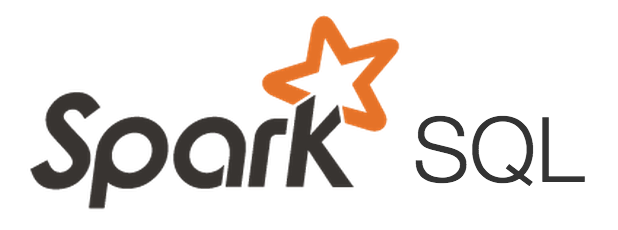

In [ ]:
from pyspark.sql.types import *

userSchema = StructType([
    StructField('employee_id',IntegerType()),
    StructField('ename',StringType()),
    StructField('salary',FloatType()),
])
dfemp3 = spark.read.csv('/content/drive/MyDrive/spark_workspace/Data_Files/emp.csv',header=True,schema=userSchema)
dfemp3.show()

+-----------+----------------+-------+
|employee_id|           ename| salary|
+-----------+----------------+-------+
|        100|     Steven King|24000.0|
|        101|   Neena Kochhar|17000.0|
|        102|     Lex De Haan|17000.0|
|        103|Alexander Hunold| 9000.0|
|        104|     Bruce Ernst| 6000.0|
|        105|    David Austin| 4800.0|
|        106| Valli Pataballa| 4800.0|
|        107|   Diana Lorentz|   null|
|        108| Nancy Greenberg|12008.0|
|        109|            null| 9000.0|
+-----------+----------------+-------+



In [ ]:
### SPQRK_SQL: Creating Temp Table
dfemp3.registerTempTable("emp")

/usr/local/lib/python3.8/dist-packages/pyspark/sql/dataframe.py:229: FutureWarning: Deprecated in 2.0, use createOrReplaceTempView instead.
  warnings.warn("Deprecated in 2.0, use createOrReplaceTempView instead.", FutureWarning)


In [ ]:
### QUERY EXECUTION
query1 = spark.sql("select ename as employee_Name from emp where salary >= 17000")
query1.show()

+-------------+
|employee_Name|
+-------------+
|  Steven King|
|Neena Kochhar|
|  Lex De Haan|
+-------------+



In [ ]:
query2 = spark.sql(' select employee_id,ename,salary from emp where employee_id%2!=0')
query2.show()

+-----------+----------------+-------+
|employee_id|           ename| salary|
+-----------+----------------+-------+
|        101|   Neena Kochhar|17000.0|
|        103|Alexander Hunold| 9000.0|
|        105|    David Austin| 4800.0|
|        107|   Diana Lorentz|   null|
|        109|            null| 9000.0|
+-----------+----------------+-------+



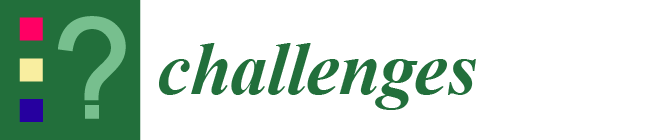

In [ ]:
from pyspark.sql.functions import *

schema = StructType ([
    StructField('ip_address',StringType()),
    StructField('country',StringType()),
    StructField('donamin_name',StringType()),
    StructField('bytes_used',IntegerType())
])

sp_ch_df = spark.read.csv('/content/drive/MyDrive/spark_workspace/Data_Files/challenge.csv',header=True, schema=schema)
sp_ch_df.show()

+---------------+--------------+-----------------+----------+
|     ip_address|       country|     donamin_name|bytes_used|
+---------------+--------------+-----------------+----------+
|  52.81.192.172|         China| odnoklassniki.ru|       463|
| 119.239.207.13|         China|         youtu.be|        51|
|  68.69.217.210|         China|        adobe.com|        10|
|   7.191.21.223|      Bulgaria|     linkedin.com|       853|
|   211.13.10.68|     Indonesia|          hud.gov|        29|
|   239.80.21.97|      Suriname|       smh.com.au|       218|
|106.214.106.233|       Jamaica|    amazonaws.com|        95|
| 127.242.24.138|         China| surveymonkey.com|       123|
|     99.2.6.139|Czech Republic|     geocities.jp|       322|
|   237.54.11.63|         China|       amazon.com|        83|
| 252.141.157.25|         Japan|      cornell.edu|       374|
|185.220.128.248|       Belgium|       weebly.com|       389|
|   151.77.19.45|   Afghanistan|independent.co.uk|       282|
|  9.161

In [ ]:
##### QUESION 1: add new column if city mexico or not
sp_ch_df1 = sp_ch_df.withColumn('isMexico',when(sp_ch_df.country=='Mexico','yes').otherwise('no'))
sp_ch_df1.show()

+---------------+--------------+-----------------+----------+--------+
|     ip_address|       country|     donamin_name|bytes_used|isMexico|
+---------------+--------------+-----------------+----------+--------+
|  52.81.192.172|         China| odnoklassniki.ru|       463|      no|
| 119.239.207.13|         China|         youtu.be|        51|      no|
|  68.69.217.210|         China|        adobe.com|        10|      no|
|   7.191.21.223|      Bulgaria|     linkedin.com|       853|      no|
|   211.13.10.68|     Indonesia|          hud.gov|        29|      no|
|   239.80.21.97|      Suriname|       smh.com.au|       218|      no|
|106.214.106.233|       Jamaica|    amazonaws.com|        95|      no|
| 127.242.24.138|         China| surveymonkey.com|       123|      no|
|     99.2.6.139|Czech Republic|     geocities.jp|       322|      no|
|   237.54.11.63|         China|       amazon.com|        83|      no|
| 252.141.157.25|         Japan|      cornell.edu|       374|      no|
|185.2

In [ ]:
##### QUESION 2: total bytes_used by new column isMexico
sp_ch_df2 = sp_ch_df1.groupby('isMexico').agg(sum('bytes_used').alias('total_used'))
sp_ch_df2.show()

+--------+----------+
|isMexico|total_used|
+--------+----------+
|      no|    508076|
|     yes|      6293|
+--------+----------+



In [ ]:
##### QUESION 3: group by country and use countDistinct function to determine ip_address has each country
sp_ch_df3 = sp_ch_df1.groupby('country').agg(countDistinct('ip_address').alias('no_of_ips'))
sp_ch_df3.sort(sp_ch_df3.no_of_ips.desc()).show()

+--------------+---------+
|       country|no_of_ips|
+--------------+---------+
|         China|      172|
|     Indonesia|      114|
|   Philippines|       65|
|        Russia|       56|
|        Brazil|       35|
|        Poland|       31|
|        Sweden|       28|
|         Japan|       25|
|Czech Republic|       23|
|      Portugal|       23|
|        France|       21|
|          Peru|       19|
|      Colombia|       17|
| United States|       15|
|     Argentina|       14|
|       Ukraine|       14|
|        Mexico|       13|
|      Thailand|       12|
|       Nigeria|       11|
|        Canada|       11|
+--------------+---------+
only showing top 20 rows



**Addtitional Information**

In [ ]:
import urllib.request
urllib.request.urlretrieve('https://github.com/datablist/sample-csv-files/raw/main/files/people/people-100.csv', 'myfile.txt')

df = spark.read.csv('myfile.txt',header=True)
df.show()

+-----+---------------+----------+---------+------+--------------------+--------------------+-------------+--------------------+
|Index|        User Id|First Name|Last Name|   Sex|               Email|               Phone|Date of birth|           Job Title|
+-----+---------------+----------+---------+------+--------------------+--------------------+-------------+--------------------+
|    1|88F7B33d2bcf9f5|    Shelby|  Terrell|  Male|elijah57@example.net|001-084-906-7849x...|   1945-10-26|     Games developer|
|    2|f90cD3E76f1A9b9|   Phillip|  Summers|Female|bethany14@example...|   214.112.6044x4913|   1910-03-24|      Phytotherapist|
|    3|DbeAb8CcdfeFC2c|  Kristine|   Travis|  Male|bthompson@example...|        277.609.7938|   1992-07-02|           Homeopath|
|    4|A31Bee3c201ef58|   Yesenia| Martinez|  Male|kaitlinkaiser@exa...|        584.094.6111|   2017-08-03|   Market researcher|
|    5|1bA7A3dc874da3c|      Lori|     Todd|  Male|buchananmanuel@ex...|   689-207-3558x7233|   1